### Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import openpyxl

import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
datos = pd.read_csv('datos_preprocesados_train_final_smote.csv')
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577 entries, 0 to 576
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            577 non-null    int64  
 1   mts2                  577 non-null    float64
 2   dormitorios           577 non-null    float64
 3   parqueos              577 non-null    float64
 4   banos                 577 non-null    float64
 5   CANT_HOSPITAL         577 non-null    float64
 6   CANT_SUPERMERCADO     577 non-null    float64
 7   hogares_lectura       577 non-null    float64
 8   hogares_techo_lamina  577 non-null    float64
 9   hogares_sin_agua      577 non-null    float64
 10  miembros_ph_avg       577 non-null    float64
 11  cnt_habit_ph_med      577 non-null    float64
 12  tipo_vivienda_avg     577 non-null    float64
 13  tipo_vivienda_le      577 non-null    int64  
 14  DEPTO_le              577 non-null    int64  
 15  DEPTO_avg             5

In [3]:
datos2 = pd.read_csv('datos_preprocesados_depurados_final.csv')
datos3 = datos2[datos2['flag_train']==1]
datos2 = datos2[datos2['flag_train']==0]
datos2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184 entries, 429 to 612
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            184 non-null    int64  
 1   mts2                  184 non-null    float64
 2   dormitorios           184 non-null    float64
 3   parqueos              184 non-null    float64
 4   banos                 184 non-null    float64
 5   CANT_HOSPITAL         184 non-null    float64
 6   CANT_SUPERMERCADO     184 non-null    float64
 7   hogares_lectura       184 non-null    float64
 8   hogares_techo_lamina  184 non-null    float64
 9   hogares_sin_agua      184 non-null    float64
 10  miembros_ph_avg       184 non-null    float64
 11  cnt_habit_ph_med      184 non-null    float64
 12  flag_train            184 non-null    int64  
 13  tipo_vivienda_avg     184 non-null    float64
 14  tipo_vivienda_le      184 non-null    int64  
 15  DEPTO_le              184 

In [4]:
datos.columns

Index(['Unnamed: 0', 'mts2', 'dormitorios', 'parqueos', 'banos',
       'CANT_HOSPITAL', 'CANT_SUPERMERCADO', 'hogares_lectura',
       'hogares_techo_lamina', 'hogares_sin_agua', 'miembros_ph_avg',
       'cnt_habit_ph_med', 'tipo_vivienda_avg', 'tipo_vivienda_le', 'DEPTO_le',
       'DEPTO_avg', 'zona_le', 'zona_avg', 'nom_dpto_le', 'nom_dpto_avg',
       'nom_mun_le', 'nom_mun_avg', 'precio', 'perfil'],
      dtype='object')

In [5]:
atributos = [x for x in datos.columns if x not in ['Unnamed: 0','precio','perfil']]

In [6]:
X = datos[atributos]
y = datos['precio']

In [7]:
cols_nas = pd.DataFrame(datos2[atributos].isna().mean()).reset_index()
cols_nas.columns = ['Variable', 'nulos']
cols_nas[cols_nas['nulos']>0].sort_values(by='nulos',ascending=False)

,Variable,nulos


In [8]:
cols_nas = pd.DataFrame(datos[atributos].isna().mean()).reset_index()
cols_nas.columns = ['Variable', 'nulos']
cols_nas[cols_nas['nulos']>0].sort_values(by='nulos',ascending=False)

,Variable,nulos


# Definición de funciones

In [9]:
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape, r2_score

def metricas(y_true, y_pred):
    resultados = {}
    resultados['RMSE'] = rmse(y_true, y_pred)
    resultados['MAPE'] = mape(y_true, y_pred)
    resultados['R2'] = r2_score(y_true, y_pred)

    # Evitar división por cero
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    error = (y_pred - y_true) / y_true

    resultados['Mediana_ErrorAbs'] = np.median(np.abs(error))
    resultados['Pct_Error<0.3'] = np.sum(np.abs(error) <= 0.3) / len(error)
    return resultados



In [10]:

def analisis_deciles(y_true, y_pred, n_deciles=10, umbral=0.3):
    """
    Evalúa el desempeño del modelo por deciles de y_true.

    Parámetros:
    -----------
    y_true : array-like
        Valores reales.
    y_pred : array-like
        Valores predichos.
    n_deciles : int, opcional (default=10)
        Número de segmentos (deciles por defecto).
    umbral : float, opcional (default=0.3)
        Umbral de error relativo (30% por defecto).

    Retorna:
    --------
    DataFrame con columnas:
        - Decil
        - y_true_min, y_true_max: rango del decil
        - %Subestimado (> +umbral)
        - %Error<umbral
        - %Sobreestimado (< -umbral)
    """

    # Convertir a DataFrame para facilidad
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).copy()

    # Evitar división por cero
    df['y_true_safe'] = np.where(df['y_true'] == 0, np.finfo(float).eps, df['y_true'])

    # Error relativo
    df['error_rel'] = (df['y_pred'] - df['y_true']) / df['y_true_safe']

    # Crear deciles de y_true
    df['decil'] = pd.qcut(df['y_true'], q=n_deciles, labels=False, duplicates='drop') + 1

    # Calcular métricas por decil
    resumen = df.groupby('decil').apply(lambda x: pd.Series({
        'y_true_min': x['y_true'].min(),
        'y_true_max': x['y_true'].max(),
        '%Subestimado(>+{:.0f}%)'.format(umbral*100): np.mean(x['error_rel'] > umbral) * 100,
        '%Error<={:.0f}%'.format(umbral*100): np.mean(np.abs(x['error_rel']) <= umbral) * 100,
        '%Sobreestimado(<-{:.0f}%)'.format(umbral*100): np.mean(x['error_rel'] < -umbral) * 100
    })).reset_index()

    return resumen

# Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

In [ ]:
param_grid = {
    'n_estimators': [50,100, 200,500],
    'max_depth': [5,10,20,50],
    'min_samples_split': [10,20]
}

In [ ]:


def cross_val_rf(X, y, param_grid, n_splits=5):
    results = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for n_estimators in param_grid['n_estimators']:
        for max_depth in param_grid['max_depth']:
            for min_samples_split in param_grid['min_samples_split']:

                  metricas_fold = []

                  for train_idx, test_idx in kf.split(X):
                      X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                      y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                      model = RandomForestRegressor(
                            n_estimators=n_estimators,
                            max_depth=max_depth,
                            min_samples_split=min_samples_split,
                            random_state=42,
                            n_jobs=-1
                        )

                      model.fit(X_train, y_train)
                      y_pred = model.predict(X_test)

                      metricas_fold.append(metricas(y_test, y_pred))

                    # Promediar métricas en los folds
                  promedio_metricas = {m: np.mean([fold[m] for fold in metricas_fold]) for m in metricas_fold[0]}

                  results.append({
                        'n_estimators': n_estimators,
                        'max_depth': max_depth,
                        'min_samples_split': min_samples_split,
                        **promedio_metricas
                    })

    return pd.DataFrame(results)

In [ ]:
resultados_random_forest = cross_val_rf(X, y, param_grid)

In [ ]:
resultados_random_forest.head()

,n_estimators,max_depth,min_samples_split,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
0,50,5,10,686252.414702,1.664678,0.613821,0.320560,0.486882
1,50,5,20,721221.831747,1.769352,0.570894,0.330594,0.467811
2,50,10,10,668991.949583,1.467497,0.635874,0.277812,0.535502
3,50,10,20,711058.624546,1.639229,0.583933,0.291957,0.512969
4,50,20,10,666896.326542,1.444691,0.637786,0.269776,0.535532


In [ ]:
resultados_random_forest.sort_values(by='Mediana_ErrorAbs', ascending=True).head(15)

,n_estimators,max_depth,min_samples_split,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
22,200,50,10,659628.941582,1.447344,0.645845,0.258767,0.554528
18,200,10,10,660421.296739,1.468270,0.644920,0.259796,0.557991
20,200,20,10,659626.408458,1.448036,0.645750,0.260166,0.554528
26,500,10,10,662099.438803,1.483426,0.642350,0.263186,0.547631
28,500,20,10,662097.243469,1.463761,0.642216,0.264010,0.549340
30,500,50,10,662044.372783,1.463515,0.642314,0.264491,0.549340
10,100,10,10,664301.395053,1.459432,0.640333,0.264905,0.552804
14,100,50,10,662701.644691,1.443538,0.641918,0.265714,0.552789
12,100,20,10,662884.533805,1.445304,0.641533,0.266562,0.552789
4,50,20,10,666896.326542,1.444691,0.637786,0.269776,0.535532


In [ ]:
resultados_random_forest.sort_values(by='Pct_Error<0.3', ascending=False).head(15)

,n_estimators,max_depth,min_samples_split,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
18,200,10,10,660421.296739,1.468270,0.644920,0.259796,0.557991
20,200,20,10,659626.408458,1.448036,0.645750,0.260166,0.554528
22,200,50,10,659628.941582,1.447344,0.645845,0.258767,0.554528
10,100,10,10,664301.395053,1.459432,0.640333,0.264905,0.552804
14,100,50,10,662701.644691,1.443538,0.641918,0.265714,0.552789
12,100,20,10,662884.533805,1.445304,0.641533,0.266562,0.552789
30,500,50,10,662044.372783,1.463515,0.642314,0.264491,0.549340
28,500,20,10,662097.243469,1.463761,0.642216,0.264010,0.549340
26,500,10,10,662099.438803,1.483426,0.642350,0.263186,0.547631
6,50,50,10,667925.846691,1.443998,0.636642,0.270567,0.535532


In [ ]:
resultados_random_forest.to_csv('resultados_random_forest.csv')

## Modelo ajustado

In [13]:
params = {
    'n_estimators': 200,
    'max_depth': 10,
    'min_samples_split': 10
}
rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
rf.fit(X, y)
y_train_pred = rf.predict(X)
metricas(y, y_train_pred)

{'RMSE': 444490.34955849755,
 'MAPE': 1.0430086676129349,
 'R2': 0.8480619717868841,
 'Mediana_ErrorAbs': np.float64(0.16970230085461618),
 'Pct_Error<0.3': np.float64(0.6897746967071057)}

In [ ]:

y_test_pred = rf.predict(datos2[atributos])
metricas(datos2['precio'], y_test_pred)

{'RMSE': 335774.5907764332,
 'MAPE': 1.3004289442655914,
 'R2': 0.6735322293448172,
 'Mediana_ErrorAbs': np.float64(0.2732993640869441),
 'Pct_Error<0.3': np.float64(0.532608695652174)}

In [14]:

y_test_pred = rf.predict(datos3[atributos])
metricas(datos3['precio'], y_test_pred)

{'RMSE': 434092.3066735595,
 'MAPE': 1.2137899507612073,
 'R2': 0.7786061284321143,
 'Mediana_ErrorAbs': np.float64(0.18747469243784096),
 'Pct_Error<0.3': np.float64(0.6736596736596736)}

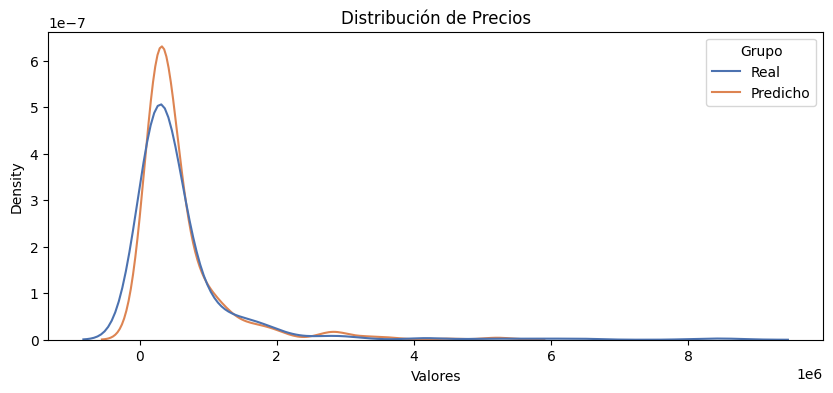

In [15]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [18]:
df.groupby('Grupo').describe(percentiles = [0.05,0.1,0.25,0.5,0.75,0.9,0.95])

Valores                                                             \
           count           mean            std           min             5%   
Grupo                                                                         
Predicho   429.0  595782.663742  678349.572372  55998.027204  118952.493836   
Real       429.0  598105.953427  923647.061937   5000.000000   60200.000000   

                                                                     \
                    10%            25%            50%           75%   
Grupo                                                                 
Predicho  165393.513159  269829.304648  346141.954794  632453.21148   
Real      108800.000000  220000.000000  325000.000000  590000.00000   

                                                    
                   90%           95%           max  
Grupo                                               
Predicho  1.205408e+06  1.776682e+06  5.293757e+06  
Real      1.209000e+06  1.800000e+06  8.625000e+06

In [ ]:
df = pd.DataFrame({'importancia':rf.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,0.534
nom_mun_avg,0.143
parqueos,0.062
CANT_SUPERMERCADO,0.053
banos,0.049
CANT_HOSPITAL,0.033
DEPTO_avg,0.021
nom_dpto_avg,0.021
hogares_lectura,0.018
hogares_sin_agua,0.016


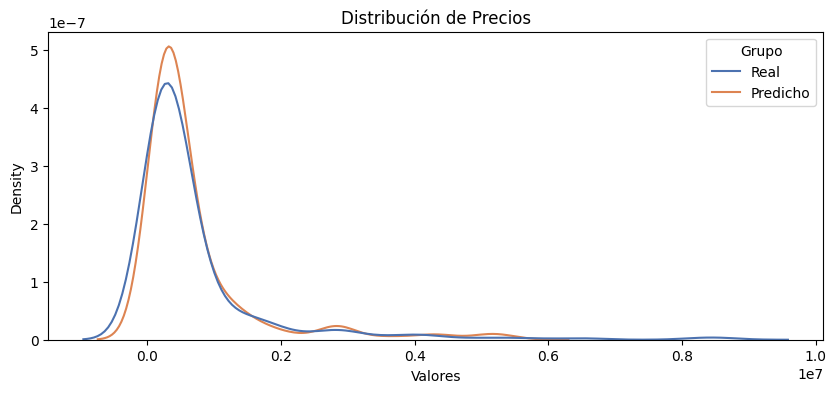

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(y), pd.Series(y_train_pred)]),
                   'Grupo': ['Real'] * len(y) + ['Predicho'] * len(y)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

Valores                                                         \
           count       mean         std       min        10%        20%   
Grupo                                                                     
Predicho 577.000 707255.620  945896.549 55998.027 149974.958 225653.674   
Real     577.000 701489.510 1141315.613  5000.000  96661.563 160000.000   

                                                                            \
                30%        40%        50%        60%        70%        80%   
Grupo                                                                        
Predicho 282322.271 313809.009 350835.064 448746.689 572621.142 850470.946   
Real     229800.000 285000.000 325000.000 403000.000 507914.017 795000.000   

                                              
                 90%        100%         max  
Grupo                                         
Predicho 1555382.079 5505888.076 5505888.076  
Real     1620000.000 8625000.000 8625000.000

In [ ]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)


In [ ]:
analisis_deciles(y, y_train_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,95498.000,70.690,29.310,0.000
1,2,97437.271,160000.000,50.847,49.153,0.000
2,3,160852.431,229000.000,41.071,58.929,0.000
3,4,230000.000,285000.000,18.750,81.250,0.000
4,5,286290.000,325000.000,11.321,86.792,1.887
5,6,325884.914,400000.000,17.857,82.143,0.000
6,7,405000.000,504892.521,10.345,87.931,1.724
7,8,520000.000,795000.000,15.517,68.966,15.517
8,9,800000.000,1600000.000,19.298,66.667,14.035
9,10,1650000.000,8625000.000,3.448,79.310,17.241


In [ ]:
analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,108000.000,81.395,18.605,0.000
1,2,109000.000,175000.000,58.140,41.860,0.000
2,3,178000.000,250000.000,30.435,69.565,0.000
3,4,254587.000,288000.000,7.317,92.683,0.000
4,5,290000.000,325000.000,11.628,86.047,2.326
5,6,330000.000,400000.000,22.727,77.273,0.000
6,7,405000.000,500000.000,4.762,92.857,2.381
7,8,520000.000,695000.000,18.605,65.116,16.279
8,9,697000.000,1200000.000,19.512,63.415,17.073
9,10,1245000.000,8625000.000,6.977,67.442,25.581


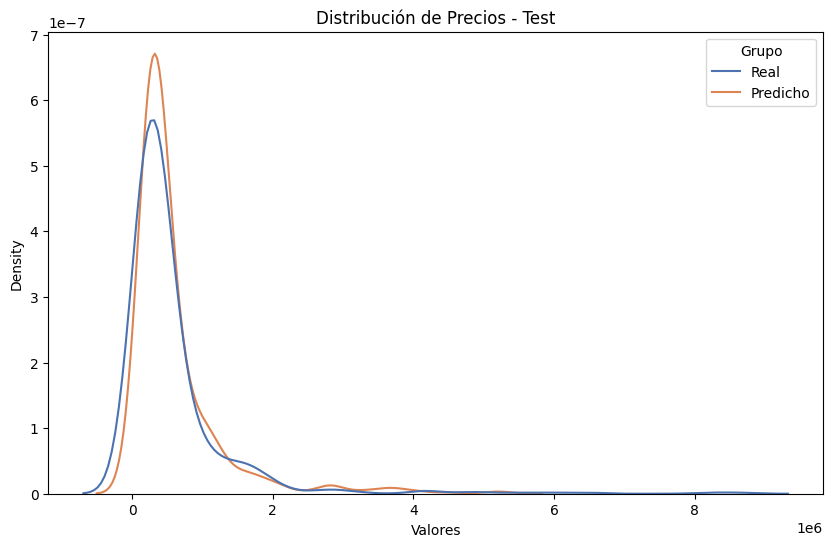

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos2['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 6))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios - Test')
plt.show()

# LightGBM

In [ ]:
import lightgbm as lgb

In [ ]:
param_grid = {
    'n_estimators': [50,100, 200,500],
    'max_depth': [5,10,20,50],
    'learning_rate': [0.01,0.05,0.1,0.5],
    'max_bin': [10,20,50,100]
}

In [ ]:
def cross_val_lgb(X, y, param_grid, n_splits=5):
    results = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for n_estimators in param_grid['n_estimators']:
        for max_depth in param_grid['max_depth']:
            for lr in param_grid['learning_rate']:
              for mb in param_grid['max_bin']:

                      metricas_fold = []

                      for train_idx, test_idx in kf.split(X):
                          X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                          y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                          model = lgb.LGBMRegressor(
                                n_estimators=n_estimators,
                                max_depth=max_depth,
                                learning_rate=lr,
                                max_bin=mb,
                                random_state=42,
                                n_jobs=-1
                            )

                          model.fit(X_train, y_train)
                          y_pred = model.predict(X_test)

                          metricas_fold.append(metricas(y_test, y_pred))

                        # Promediar métricas en los folds
                      promedio_metricas = {m: np.mean([fold[m] for fold in metricas_fold]) for m in metricas_fold[0]}

                      results.append({
                            'n_estimators': n_estimators,
                            'max_depth': max_depth,
                            'learning_rate': lr,
                            'max_bin': mb,
                            **promedio_metricas
                        })

    return pd.DataFrame(results)

In [ ]:
resultados_random_lgbm = cross_val_lgb(X, y, param_grid)

Se han truncado las últimas 5000 líneas del flujo de salida.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [ ]:
resultados_random_lgbm.head()

,n_estimators,max_depth,learning_rate,max_bin,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
0,50,5,0.01,10,925316.821695,2.640642,0.295905,0.787014,0.190615
1,50,5,0.01,20,929799.419608,2.642985,0.293463,0.799524,0.176732
2,50,5,0.01,50,925945.785488,2.607217,0.298072,0.784396,0.183763
3,50,5,0.01,100,925488.834794,2.679500,0.297130,0.794440,0.182024
4,50,5,0.05,10,759034.280391,1.977478,0.522330,0.336405,0.461139


In [ ]:
resultados_random_lgbm.sort_values(by='Mediana_ErrorAbs', ascending=True).head(15)

,n_estimators,max_depth,learning_rate,max_bin,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
26,50,10,0.10,50,703581.186208,1.689553,0.581854,0.271870,0.530345
42,50,20,0.10,50,705596.747248,1.677642,0.578055,0.285113,0.511244
58,50,50,0.10,50,705596.747248,1.677642,0.578055,0.285113,0.511244
24,50,10,0.10,10,732533.452889,1.778254,0.553081,0.285231,0.516537
106,100,20,0.10,50,689243.801120,1.638758,0.593558,0.286423,0.513043
122,100,50,0.10,50,689243.801120,1.638758,0.593558,0.286423,0.513043
210,500,10,0.01,50,706587.150124,1.672772,0.576693,0.287160,0.514708
118,100,50,0.05,50,703382.868774,1.673811,0.581491,0.287938,0.511184
102,100,20,0.05,50,703382.868774,1.673811,0.581491,0.287938,0.511184
84,100,10,0.05,10,730211.977620,1.826707,0.554624,0.291514,0.492369


In [ ]:
resultados_random_lgbm.sort_values(by='Pct_Error<0.3', ascending=False).head(15)

,n_estimators,max_depth,learning_rate,max_bin,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
26,50,10,0.10,50,703581.186208,1.689553,0.581854,0.271870,0.530345
24,50,10,0.10,10,732533.452889,1.778254,0.553081,0.285231,0.516537
103,100,20,0.05,100,697680.842387,1.668542,0.583008,0.291556,0.514738
119,100,50,0.05,100,697680.842387,1.668542,0.583008,0.291556,0.514738
210,500,10,0.01,50,706587.150124,1.672772,0.576693,0.287160,0.514708
122,100,50,0.10,50,689243.801120,1.638758,0.593558,0.286423,0.513043
106,100,20,0.10,50,689243.801120,1.638758,0.593558,0.286423,0.513043
58,50,50,0.10,50,705596.747248,1.677642,0.578055,0.285113,0.511244
42,50,20,0.10,50,705596.747248,1.677642,0.578055,0.285113,0.511244
134,200,5,0.05,50,687373.989841,1.695199,0.598378,0.307713,0.511229


In [ ]:
resultados_random_lgbm.to_csv('resultados_lgbm.csv')

## Modelo ajustado

In [ ]:
params = {
    'n_estimators': 50,
    'max_depth': 10,
    'learning_rate': 0.10,
    'max_bin': 50
}
lgbm = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1)
lgbm.fit(X, y)
y_train_pred = lgbm.predict(X)
metricas(y, y_train_pred)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 527
[LightGBM] [Info] Number of data points in the train set: 577, number of used features: 21
[LightGBM] [Info] Start training from score 701489.510070
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

{'RMSE': 577709.7231128645,
 'MAPE': 1.2646233276802261,
 'R2': 0.7433382404243949,
 'Mediana_ErrorAbs': np.float64(0.20007896487266957),
 'Pct_Error<0.3': np.float64(0.6169844020797227)}

In [ ]:
df = pd.DataFrame({'importancia':lgbm.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
mts2,300
parqueos,95
CANT_SUPERMERCADO,90
banos,84
nom_mun_avg,73
CANT_HOSPITAL,58
tipo_vivienda_avg,32
hogares_lectura,32
dormitorios,31
hogares_techo_lamina,23


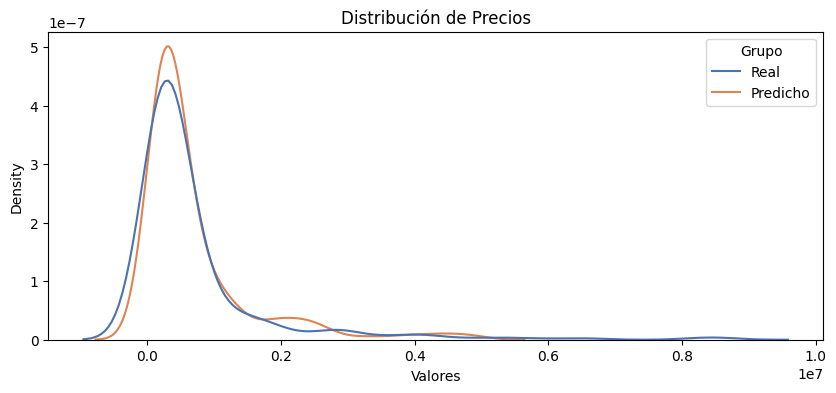

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(y), pd.Series(y_train_pred)]),
                   'Grupo': ['Real'] * len(y) + ['Predicho'] * len(y)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

Valores                                                          \
           count       mean         std        min        10%        20%   
Grupo                                                                      
Predicho 577.000 701489.510  876664.231 -35320.313 127789.448 186941.577   
Real     577.000 701489.510 1141315.613   5000.000  96661.563 160000.000   

                                                                            \
                30%        40%        50%        60%        70%        80%   
Grupo                                                                        
Predicho 261854.452 316748.043 374731.569 467064.919 629272.612 965650.616   
Real     229800.000 285000.000 325000.000 403000.000 507914.017 795000.000   

                                              
                 90%        100%         max  
Grupo                                         
Predicho 1894502.332 4907075.501 4907075.501  
Real     1620000.000 8625000.000 8625000.000

In [ ]:
analisis_deciles(y, y_train_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,95498.000,67.241,15.517,17.241
1,2,97437.271,160000.000,40.678,50.847,8.475
2,3,160852.431,229000.000,37.500,53.571,8.929
3,4,230000.000,285000.000,17.188,73.438,9.375
4,5,286290.000,325000.000,11.321,83.019,5.660
5,6,325884.914,400000.000,19.643,75.000,5.357
6,7,405000.000,504892.521,22.414,74.138,3.448
7,8,520000.000,795000.000,20.690,58.621,20.690
8,9,800000.000,1600000.000,26.316,56.140,17.544
9,10,1650000.000,8625000.000,1.724,77.586,20.690


In [ ]:

y_test_pred = lgbm.predict(datos3[atributos])
metricas(datos3['precio'], y_test_pred)

{'RMSE': 552363.834533372,
 'MAPE': 1.3590627752080662,
 'R2': 0.6415307653250848,
 'Mediana_ErrorAbs': np.float64(0.19845329588053912),
 'Pct_Error<0.3': np.float64(0.6293706293706294)}

In [ ]:

analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,108000.000,76.744,6.977,16.279
1,2,109000.000,175000.000,37.209,55.814,6.977
2,3,178000.000,250000.000,28.261,67.391,4.348
3,4,254587.000,288000.000,9.756,85.366,4.878
4,5,290000.000,325000.000,11.628,83.721,4.651
5,6,330000.000,400000.000,20.455,77.273,2.273
6,7,405000.000,500000.000,19.048,76.190,4.762
7,8,520000.000,695000.000,18.605,60.465,20.930
8,9,697000.000,1200000.000,26.829,56.098,17.073
9,10,1245000.000,8625000.000,6.977,60.465,32.558


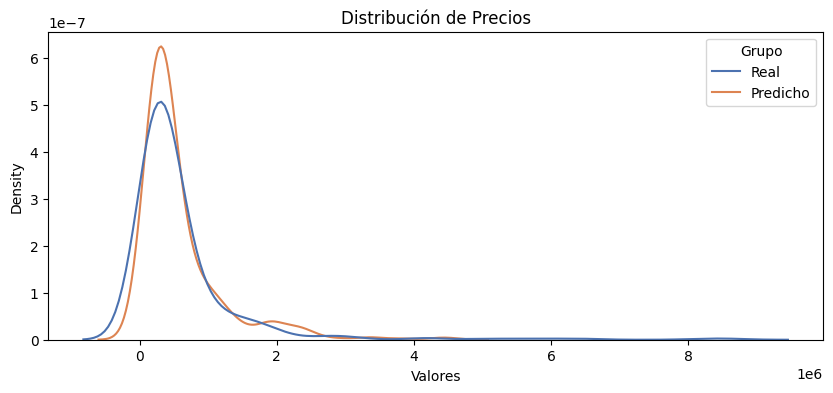

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

# XGBoost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
param_grid = {
    'gamma': [0,0.5,1],
    'max_depth': [5,10,20,50],
    'learning_rate': [0.01,0.05,0.1,0.5],
    'lambda': [1]
}


In [ ]:
def cross_val_xgb(X, y, param_grid, n_splits=5):
    results = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for gam in param_grid['gamma']:
        for max_depth in param_grid['max_depth']:
            for lr in param_grid['learning_rate']:
              for lb in param_grid['lambda']:

                      metricas_fold = []

                      for train_idx, test_idx in kf.split(X):
                          X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
                          y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

                          model = XGBRegressor(
                                gamma=gam,
                                max_depth=max_depth,
                                learning_rate=lr,
                                random_state=42,
                                n_jobs=-1
                            )

                          model.fit(X_train, y_train)
                          y_pred = model.predict(X_test)

                          metricas_fold.append(metricas(y_test, y_pred))

                        # Promediar métricas en los folds
                      promedio_metricas = {m: np.mean([fold[m] for fold in metricas_fold]) for m in metricas_fold[0]}

                      results.append({
                            'gamma': gam,
                            'max_depth': max_depth,
                            'learning_rate': lr,
                            'lambda': lb,
                            **promedio_metricas
                        })

    return pd.DataFrame(results)

In [ ]:
resultados_random_xgb = cross_val_xgb(X, y, param_grid)

In [ ]:
resultados_random_xgb.head()

,gamma,max_depth,learning_rate,lambda,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
0,0.0,5,0.01,1,763341.700897,2.147052,0.521222,0.547607,0.287721
1,0.0,5,0.05,1,705055.673366,1.450536,0.576088,0.280614,0.526762
2,0.0,5,0.10,1,703474.740064,1.269223,0.578123,0.253838,0.561544
3,0.0,5,0.50,1,734913.619238,1.279178,0.552102,0.287378,0.500945
4,0.0,10,0.01,1,737725.201979,1.887878,0.561941,0.549371,0.286027


In [ ]:
resultados_random_xgb.sort_values(by='MAPE', ascending=True).head(15)

,gamma,max_depth,learning_rate,lambda,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
6,0.0,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
22,0.5,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
38,1.0,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
21,0.5,10,0.05,1,691933.979894,1.221446,0.608313,0.235270,0.573658
37,1.0,10,0.05,1,691933.979894,1.221446,0.608313,0.235270,0.573658
5,0.0,10,0.05,1,691933.979894,1.221446,0.608313,0.235270,0.573658
10,0.0,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033
26,0.5,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033
42,1.0,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033
41,1.0,20,0.05,1,702501.216200,1.232733,0.593182,0.231937,0.584003


In [ ]:
resultados_random_xgb.sort_values(by='Mediana_ErrorAbs', ascending=True).head(15)

,gamma,max_depth,learning_rate,lambda,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
6,0.0,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
22,0.5,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
38,1.0,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
26,0.5,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033
42,1.0,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033
10,0.0,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033
14,0.0,50,0.10,1,710947.455355,1.234084,0.583645,0.230863,0.587496
30,0.5,50,0.10,1,710947.459477,1.234086,0.583645,0.230863,0.587496
46,1.0,50,0.10,1,710947.458961,1.234086,0.583645,0.230863,0.587496
41,1.0,20,0.05,1,702501.216200,1.232733,0.593182,0.231937,0.584003


In [ ]:
resultados_random_xgb.sort_values(by='Pct_Error<0.3', ascending=False).head(15)

,gamma,max_depth,learning_rate,lambda,RMSE,MAPE,R2,Mediana_ErrorAbs,Pct_Error<0.3
6,0.0,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
22,0.5,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
38,1.0,10,0.10,1,705130.901666,1.213006,0.593662,0.222148,0.587601
14,0.0,50,0.10,1,710947.455355,1.234084,0.583645,0.230863,0.587496
30,0.5,50,0.10,1,710947.459477,1.234086,0.583645,0.230863,0.587496
46,1.0,50,0.10,1,710947.458961,1.234086,0.583645,0.230863,0.587496
13,0.0,50,0.05,1,702879.721952,1.234811,0.592805,0.232994,0.587481
29,0.5,50,0.05,1,702879.721952,1.234811,0.592805,0.232994,0.587481
45,1.0,50,0.05,1,702879.721952,1.234811,0.592805,0.232994,0.587481
42,1.0,20,0.10,1,710949.918056,1.229737,0.583648,0.227375,0.584033


In [ ]:
resultados_random_xgb.to_csv('resultados_xgb.csv')

## Modelo ajustado

In [ ]:
params = {
    'gamma': 0,
    'max_depth': 10,
    'learning_rate': 0.10
}
lgbm = XGBRegressor(**params, random_state=42, n_jobs=-1)
lgbm.fit(X, y)
y_train_pred = lgbm.predict(X)
metricas(y, y_train_pred)

{'RMSE': 58333.73689129789,
 'MAPE': 0.4755098857471402,
 'R2': 0.9973831344478089,
 'Mediana_ErrorAbs': np.float64(0.02223298076923077),
 'Pct_Error<0.3': np.float64(0.9532062391681109)}

In [ ]:
df = pd.DataFrame({'importancia':lgbm.feature_importances_}, index = X.columns)
df.sort_values(by='importancia', ascending=False)

,importancia
cnt_habit_ph_med,0.549
nom_mun_avg,0.136
zona_le,0.061
DEPTO_avg,0.057
mts2,0.041
hogares_lectura,0.035
parqueos,0.032
CANT_SUPERMERCADO,0.032
hogares_sin_agua,0.013
miembros_ph_avg,0.012


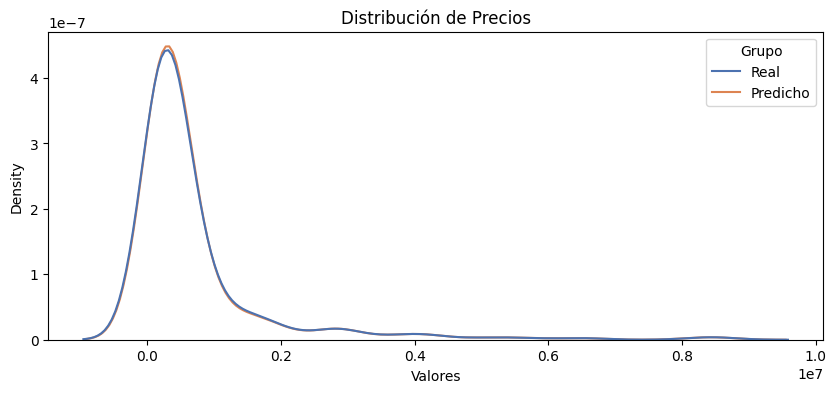

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(y), pd.Series(y_train_pred)]),
                   'Grupo': ['Real'] * len(y) + ['Predicho'] * len(y)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

In [ ]:
df.groupby('Grupo').describe(percentiles = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

Valores                                                         \
           count       mean         std       min        10%        20%   
Grupo                                                                     
Predicho 577.000 701134.861 1136301.522 20990.982 103325.983 166201.244   
Real     577.000 701489.510 1141315.613  5000.000  96661.563 160000.000   

                                                                            \
                30%        40%        50%        60%        70%        80%   
Grupo                                                                        
Predicho 241847.859 286071.350 328328.594 421971.950 507959.869 734042.688   
Real     229800.000 285000.000 325000.000 403000.000 507914.017 795000.000   

                                              
                 90%        100%         max  
Grupo                                         
Predicho 1624466.250 8594261.000 8594261.000  
Real     1620000.000 8625000.000 8625000.000

In [ ]:
analisis_deciles(y, y_train_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,95498.000,18.966,81.034,0.000
1,2,97437.271,160000.000,3.390,96.610,0.000
2,3,160852.431,229000.000,8.929,91.071,0.000
3,4,230000.000,285000.000,3.125,96.875,0.000
4,5,286290.000,325000.000,1.887,98.113,0.000
5,6,325884.914,400000.000,0.000,100.000,0.000
6,7,405000.000,504892.521,0.000,96.552,3.448
7,8,520000.000,795000.000,0.000,96.552,3.448
8,9,800000.000,1600000.000,0.000,96.491,3.509
9,10,1650000.000,8625000.000,0.000,100.000,0.000


In [ ]:

y_test_pred = lgbm.predict(datos3[atributos])
metricas(datos3['precio'], y_test_pred)

{'RMSE': 67516.60712690443,
 'MAPE': 0.6317995679868058,
 'R2': 0.9946442211414148,
 'Mediana_ErrorAbs': np.float64(0.02908125),
 'Pct_Error<0.3': np.float64(0.9393939393939394)}

In [ ]:

analisis_deciles(datos3['precio'], y_test_pred)

/tmp/ipython-input-2022482865.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resumen = df.groupby('decil').apply(lambda x: pd.Series({


,decil,y_true_min,y_true_max,%Subestimado(>+30%),%Error<=30%,%Sobreestimado(<-30%)
0,1,5000.000,108000.000,25.581,74.419,0.000
1,2,109000.000,175000.000,11.628,88.372,0.000
2,3,178000.000,250000.000,2.174,97.826,0.000
3,4,254587.000,288000.000,4.878,95.122,0.000
4,5,290000.000,325000.000,2.326,97.674,0.000
5,6,330000.000,400000.000,0.000,100.000,0.000
6,7,405000.000,500000.000,0.000,95.238,4.762
7,8,520000.000,695000.000,0.000,97.674,2.326
8,9,697000.000,1200000.000,0.000,92.683,7.317
9,10,1245000.000,8625000.000,0.000,100.000,0.000


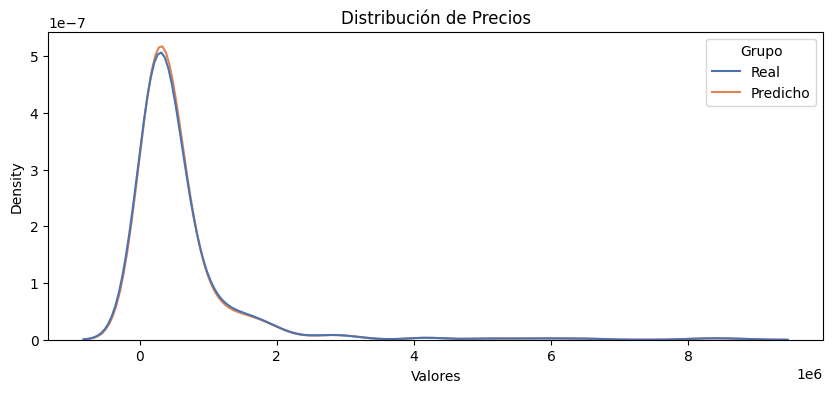

In [ ]:
df = pd.DataFrame({'Valores': pd.concat([pd.Series(datos3['precio']), pd.Series(y_test_pred)]),
                   'Grupo': ['Real'] * len(y_test_pred) + ['Predicho'] * len(y_test_pred)})

plt.figure(figsize=(10, 4))
sns.kdeplot(x='Valores', hue='Grupo', data=df, palette='deep')
plt.title('Distribución de Precios')
plt.show()

#